<a href="https://colab.research.google.com/github/maccaronibud/maccaronibud/blob/main/MiniProj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re

# 1. Load template file
df = pd.read_csv('human_vs_computer_codes_template.csv')

# 2. Cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove whitespaces and clean tabs/newlines
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Apply cleaning to exact columns
df['human_code_clean'] = df['human_code'].apply(clean_text)
df['computer_code_clean'] = df['computer_generated_code'].apply(clean_text)

print("Data loaded and cleaned successfully!")
# Preview the first few rows
df[['human_code_clean', 'computer_code_clean']].head()

Data loaded and cleaned successfully!


,human_code_clean,computer_code_clean
0,long wait time,delayed assistance
1,clear communication,supportive explanation
2,navigation difficulty,difficulty locating office
3,smooth process,efficient process
4,lack of response,unanswered email frustration


In [ ]:
# Install the library needed for text embeddings
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import pandas as pd

# Load model and convert columns to vectors
model = SentenceTransformer('all-MiniLM-L6-v2')
human_embeddings = model.encode(df['human_code_clean'].tolist(), show_progress_bar=True)
computer_embeddings = model.encode(df['computer_code_clean'].tolist(), show_progress_bar=True)

# 1. Cosine Similarity to Percentage
similarity_matrix = cosine_similarity(human_embeddings, computer_embeddings)
cosine_scores = np.diag(similarity_matrix)
df['cosine_match_pct'] = [f"{score * 100:.1f}%" for score in cosine_scores]

# 2. Euclidean Distance converted to a Match Percentage
distance_matrix = euclidean_distances(human_embeddings, computer_embeddings)
euclidean_dists = np.diag(distance_matrix)
# Formula: 1 / (1 + distance) converted to a percentage string
euclidean_pcts = [1 / (1 + d) for d in euclidean_dists]
df['euclidean_match_pct'] = [f"{pct * 100:.1f}%" for pct in euclidean_pcts]

print("\nPercentages complete! Look at how closely aligned both perspectives are:")
df[['human_code', 'computer_generated_code', 'cosine_match_pct', 'euclidean_match_pct']].head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Percentages complete! Look at how closely aligned both perspectives are:


,human_code,computer_generated_code,cosine_match_pct,euclidean_match_pct
0,long wait time,delayed assistance,35.8%,46.9%
1,clear communication,supportive explanation,17.7%,43.8%
2,navigation difficulty,difficulty locating office,24.2%,44.8%
3,smooth process,efficient process,60.7%,53.0%
4,lack of response,unanswered email frustration,36.5%,47.0%


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


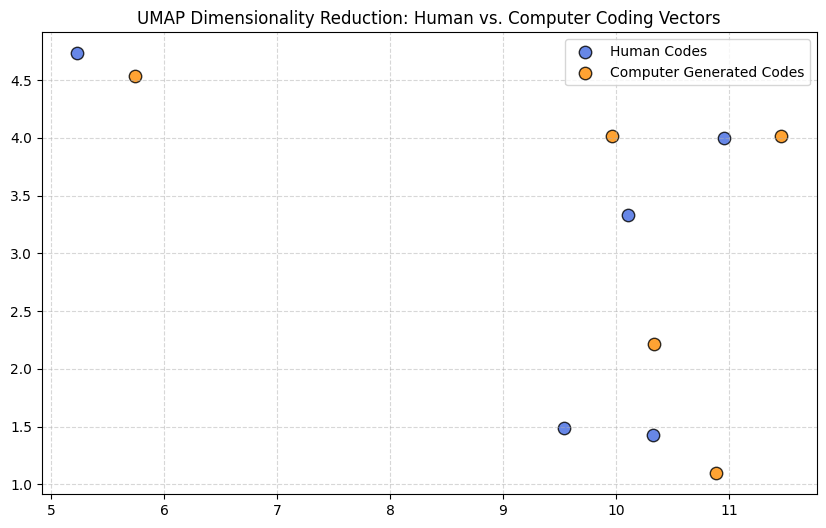

In [ ]:
# Install UMAP library
!pip install -q umap-learn[plot]

import umap
import matplotlib.pyplot as plt

# Merge embeddings for mapping
all_embeddings = np.vstack([human_embeddings, computer_embeddings])

# Build the 2D reducer
reducer = umap.UMAP(n_neighbors=3, min_dist=0.1, random_state=42) # n_neighbors adjusted for smaller template size
embedding_2d = reducer.fit_transform(all_embeddings)

# Plotting
plt.figure(figsize=(10, 6))
num_human = len(human_embeddings)

plt.scatter(embedding_2d[:num_human, 0], embedding_2d[:num_human, 1],
            c='royalblue', label='Human Codes', alpha=0.8, edgecolors='k', s=80)
plt.scatter(embedding_2d[num_human:, 0], embedding_2d[num_human:, 1],
            c='darkorange', label='Computer Generated Codes', alpha=0.8, edgecolors='k', s=80)

plt.title('UMAP Dimensionality Reduction: Human vs. Computer Coding Vectors')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Summary: The mapping suggests that the LLM is very effective in proccessing and analyzing qualatative data. The Cosine Similarity scores are decently high within a range of .2 to .3, and some outliars like 0.6. I added a euclidean measuring system aswell to double check the cosine similarity and it seems like they match. The UMAP displays clusters of related vectors which are related. However, the Cosine Similarity and Euclidean Similarity are not perfect since the LLM tends to use more formal vocabulary.